## f114111121 曾定益  數位訊號處理期末報告  
### Fractional Kaiser Window With Application to Finite Impulse Response Digital Filter Design


### 1. 問題背景

用窗函數設計濾波器時，在頻域的斷口處會產生 **Gibbs Phenomenon（吉布斯震盪）**。  

![Fig. 2](images/圖6.png)


### 2. 原本方法

使用標準 **Bessel function** 函數（公式 27）帶入 **Kaiser 窗函數**（公式 29）來設計濾波器。  
此方法的原始效能已經不錯，但論文作者提出可以進一步提升效能。

### 3. 論文方法

#### Step 1  :將（公式 27）多一個變數 **gamma** 形成（公式 28），再帶入 Kaiser 窗函數（公式 29）。 ，當 **gamma = 1** 時即退化為原本的（公式 27）。  ，新增的 **gamma** 即為論文提出的 **Fractional Kaiser Window**，且其取值為 **小於 1** 的數。

#### Step 2  :將窗函數公式（29）乘上濾波器公式（34），得到實際濾波器係數公式（33）。

#### Step 3  :將公式（33）所得的濾波器係數進行 DTFT，利用公式（30）轉換至頻域， 以判斷是否成功降低 Gibbs Phenomenon。

#### Step 4  :將透過公式（30）得到的頻譜結果依公式（32）進行正規化，  得到我們所需觀察的數值（dB）。

#### Step 5  :由圖 7 說明如何由頻域圖量化上述計算得到的 dB， 亦即本文所關注的阻帶衰減量 \( A_s \)。


### 4. 驗證方法

主要觀察 **阻帶衰減量 \( A_s \)**（minimum stopband attenuation, As）。  
其單位為 **dB**，數值越大越好，代表雜訊抑制能力越強，  
在頻率響應圖上越接近負無限大。

> “The Gibbs oscillations ,..., when evaluating the performance of the digital filters, calculating only one attenuation parameter (typically As) related with the oscillations in these regions is sufficient.”


### 5. 論文驗證

#### 5-1  :由 **圖 14、圖 15** 比較 **gamma < 1、gamma > 1、gamma = 1** 時的阻帶衰減量 \( A_s \)，  檢驗是否在 **gamma < 1** 時 \( A_s \) 數值最大。

#### 5-2  :閱讀實作結果 **圖 8** 以及 **表格 5** 後，  由 **圖 28** 找到在 \( N = 51 \) 時的最佳化參數 **alpha、gamma**。

#### 5-3  :由 **圖 30** 與論文 **II. WINDOW FUNCTIONS IN LITERATURE** 中過去各種窗函數比較，  觀察哪一種窗函數具有最大的阻帶衰減量 \( A_s \)。


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, i0
from scipy.signal import freqz
import pandas as pd

**Eq. 28: Fractional Modified Bessel Function of the first kind with zero order.**  
![Fig. 2](images/28.png)

**論文原文：**  
> it was found that using 20 terms in the summation given by (28) is sufficient(前 20 項 (k=0 to 20))


In [ ]:
def fractional_bessel_i0(z, gamma_val, k_terms=20):
    
    result = 0.0
    z_div_2 = z / 2.0
    
    for k in range(k_terms):
        # 分母：Γ(γk + 1) * Γ(k + 1)
        denom = gamma(gamma_val * k + 1) * gamma(k + 1)
        numerator = (z_div_2) ** (2 * k)
        result += numerator / denom
        
    return result


`z` → 公式裡的 ( z )

`gamma_val` → 分數階參數 ( \gamma )

`k_terms` → 級數取前幾項（論文說 **20 項就夠精確**）

$
I_0^{\gamma}(z)
$

- for k in range(k_terms)


$
\sum_{k=0}^{\infty}
$

- 公式分母:denom = gamma(gamma_val * k + 1) * gamma(k + 1)

$
\Gamma(\gamma k + 1)\Gamma(k + 1)
$

- 公式分子:numerator = (z_div_2) ** (2 * k)

$
\left(\frac{z}{2}\right)^{2k}
$

- 每一項的累加：result += numerator / denom


$
\frac{(z/2)^{2k}}{\Gamma(\gamma k + 1)\Gamma(k + 1)}
$


- return result

得到 $( I_0^{\gamma}(z) )$。   

---

**Eq. 29: Proposed Fractional Kaiser Window w(n).**
    
- Parameters參數:

alpha: Shape parameter (α)，Kaiser 窗形狀參數




![Fig. 1](images/29.png)

Returns
w: numpy array of window values

In [4]:

def fractional_kaiser_window(N, alpha, gamma_val):

    n = np.arange(N)
    # 定義範圍中心
    mid = (N - 1) / 2.0
    
    # 陣列索引 k (0 到 N-1) 來看， n = k - (N-1)/2
    n_centered = n - mid
    
    # 計算根號內的項
    arg_term = 1 - (n_centered / mid)**2
    
    # 處理邊界誤差，避免負數開根號 (浮點數運算可能有誤差)
    arg_term = np.maximum(arg_term, 0)
    
    numerator_arg = alpha * np.sqrt(arg_term)
    
    numerator = fractional_bessel_i0(numerator_arg, gamma_val)
    denominator = fractional_bessel_i0(alpha, gamma_val)
    
    w = numerator / denominator
    return w


**Eq. 34: Ideal Low-pass filter impulse response.**
- h_id(n):濾波器設計函數 

![Fig. 3](images/34.png)

In [5]:
def ideal_lowpass(wc, N):

    n = np.arange(N)
    mid = (N - 1) / 2.0
    n_centered = n - mid
    
    # sin(x)/x 當 x趨近0 時極限為 1，但在這裡係數是 wc/pi
    # h_id(0) = wc / pi
    
    h_id = np.zeros(N)
    
    #n != 0 避免除以零
    with np.errstate(divide='ignore', invalid='ignore'):
        h_id = np.sin(wc * n_centered) / (np.pi * n_centered)
    
    # n = 0
    if N % 2 != 0:
        h_id[int(mid)] = wc / np.pi
    else:
        # 偶數長度沒有整數中心點，不需要修正，上述公式有效
        pass
        
    return h_id


**Eq. 33: h_nc(n) = w(n) * h_id(n)**

![Fig. 4](images/33.png)

In [6]:

def design_fir_filter(N, wc, alpha, gamma_val):

    w = fractional_kaiser_window(N, alpha, gamma_val)
    h_id = ideal_lowpass(wc, N)
    h = w * h_id
    return h, w


**Eq. 30: 轉頻域（DTFT）**

![Fig. 5](images/30.png)

**Eq. 32: 正規化頻譜**

![Fig. 6](images/32.png)

- 這個正規化後的數值db，就論文要驗證的阻帶衰減量A_s(db)


In [7]:
def analyze_filter_spectrum(h, fs=2.0):
    M = 4096 
    # FFT 取樣點數
    # 用很多頻率點去逼近 DTFT 的連續頻譜，頻譜看起來平滑準確
    #公式30
    w, H = freqz(h, worN=M)
    
    # 轉換頻率軸為 rad/s (0 ~ pi)
    # freqz 回傳就是 0 到 pi
    w_rad = w 
    
    #頻譜本體∣A(ω)∣
    mag = np.abs(H)

    #公式32
    max_mag = np.max(mag)
    H_db = 20 * np.log10(mag / max_mag + 1e-12) 
    
    return w_rad, H_db


freqz()做FFT
$
H(e^{j\omega}) = \sum_{n=0}^{N-1} h(n) e^{-j\omega n}
$


論文後續數據觀察形式如下圖

![Fig. 6](images/圖11.png)

上一步轉頻域來觀察，後正規化數值，回傳w_rad, H_db，就是橫軸縱軸

---

**論文裡並未說明阻帶衰減量 A_S 的公式如何量測，但有圖7說明如何用頻域圖來量化上面算的db，也就這邊要求的A_s**

- 論文原文:
>“Figure 7 illustrates the normalized amplitude spectrum of a low-pass filter, showing its spectral parameters:..., and minimum stopband attenuation (As).”

>“The Gibbs oscillations ,..., when evaluating the performance of the digital filters, calculating only one attenuation parameter (typically As) related with the oscillations in these regions is sufficient.”

>" A filter having the largest minimum stopband attenuation is said to be the best one in this case.”

![Fig. 6](images/圖7.png)

- **passband frequency ($\omega_p$)**
- **stopband frequency ($\omega_{st}$)**
- **sampling frequency ($\omega_s$)**
- **maximum pass-band attenuation ($A_p$)**
- **minimum stopband attenuation ($A_s$)**


- **Stopband Attenuation (As)**
- **中文:阻帶衰減量**
- 定義:是stop band peak阻帶波峰與 0dB 的距離，是阻帶中最大旁瓣的峰值(如下圖圈起來來處為旁瓣最大峰值)以及圖6
- 因為論文圖7沒有給出具體用多少 dB 定義 passband/stopband edge，又As是指阻帶中最大旁瓣的峰值，所以程式碼整個內容就是在設計在假設passband/stopband edge，並找出阻帶中最大旁瓣的峰值 


![Fig. 6](images/cp.png)
![Fig. 6](images/圖6.png)

Section V-D 論文原文：
>"...for a cutoff frequency of $\omega_c = 0.4\pi$ rad/sample."

In [8]:
wc_target = 0.4 * np.pi  

In [9]:
def measure_metrics(w_rad, H_db, wc_target):
    
    #找出所有頻率大於截止頻率 (wc_target)
    #阻帶Stopband 位於截止頻率之後，從 wc_target 開始往後找，第一個遇到的波峰就是阻帶的第一個旁瓣。
    idx_stopband = np.where(w_rad > wc_target)[0]
    if len(idx_stopband) == 0:
        return 0, 0
    
    stopband_response = H_db[idx_stopband]
    
    peaks = []

    #搜尋每個點，如果某點的值比它左邊和右邊都大，那它就是一個局部最大值也就是一個波峰。
    for i in range(1, len(stopband_response)-1):
        if stopband_response[i] > stopband_response[i-1] and stopband_response[i] > stopband_response[i+1]:
            peaks.append(stopband_response[i])
            
    if not peaks:
       
        As = -np.min(stopband_response)
    else:
        
        As = -np.max(peaks)
    
    return As

## 以上是數學函式公式的呈現

---

## 以下進入圖片 表格復刻

 Figure 3 (時域形狀)


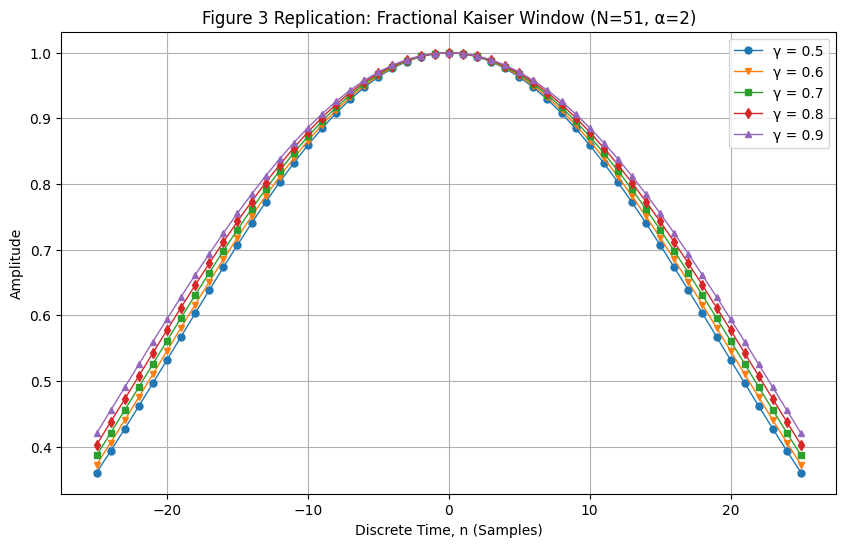

In [10]:
def plot_figure_3():
    N = 51
    alpha = 2
    gammas = [0.5, 0.6, 0.7, 0.8, 0.9]
    n = np.arange(-(N-1)/2, (N-1)/2 + 1) 
    
    plt.figure(figsize=(10, 6))
    
    markers = ['o', 'v', 's', 'd', '^']
    
    for i, g in enumerate(gammas):
        w = fractional_kaiser_window(N, alpha, g)
        plt.plot(n, w, marker=markers[i%len(markers)], label=f'γ = {g}', markersize=5, linestyle='-', linewidth=1)
        
    plt.title(f'Figure 3 Replication: Fractional Kaiser Window (N={N}, α={alpha})')
    plt.xlabel('Discrete Time, n (Samples)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.show()

print(" Figure 3 (時域形狀)")
plot_figure_3()


時域型態，0.5 $\to$ 0.9，gamma越大，能量分布更廣，但論文是以頻域為觀察對象，故此圖並不能說明甚麼

## 1. 比較alpha gamma及尋找最佳解

 Figure 8 (頻譜 vs Alpha)


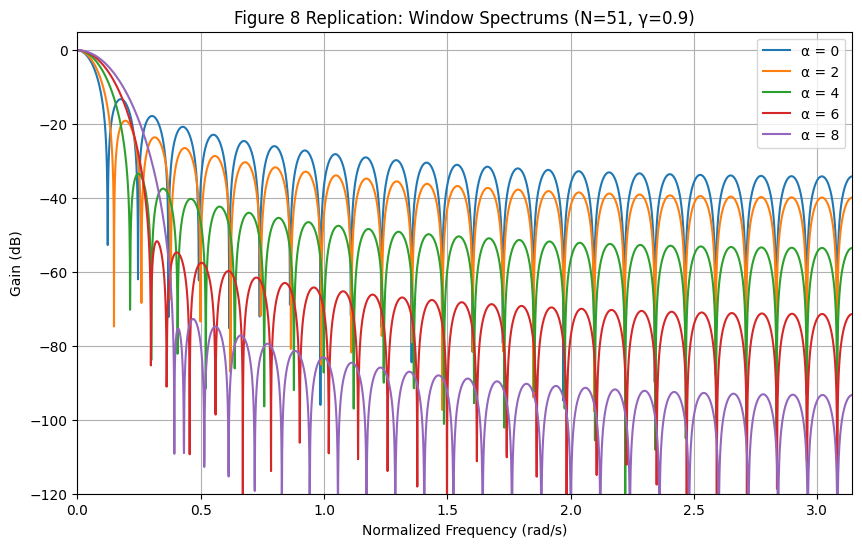

In [ ]:
def plot_figure_8():

    N = 51
    gamma_val = 0.9
    alphas = [0, 2, 4, 6, 8]
    
    plt.figure(figsize=(10, 6))
    
    for a in alphas:
        w_seq = fractional_kaiser_window(N, a, gamma_val)
        w_freq, H_db = analyze_filter_spectrum(w_seq)
        plt.plot(w_freq, H_db, label=f'α = {a}')
        
    plt.title(f'Figure 8 Replication: Window Spectrums (N={N}, γ={gamma_val})')
    plt.xlabel('Normalized Frequency (rad/s)')
    plt.ylabel('Gain (dB)')
    plt.ylim(-120, 5) 
    plt.xlim(0, np.pi)
    plt.legend()
    plt.grid(True)
    plt.show()

print(" Figure 8 (頻譜 vs Alpha)")
plot_figure_8()

![Fig. 6](images/圖8.png)

| 項目 | 說明 | 
|---|---|
| **我的結果** | $\alpha=0$ (最上面/藍色)：主瓣很窄，但旁瓣很高（衰減較差，只有 -13dB 左右）。$\alpha=8$ (最下面/黃色)：主瓣變得很寬，但旁瓣被壓得非常低（衰減極好，達到 -80dB 以下） |  
| **跟論文比較** | 數據趨勢皆相符 |  


In [12]:
def replicate_table_5():

    alpha = 2
    gammas = [0.5, 0.6, 0.7, 0.8, 0.9]
    Ns = [51, 71, 101]
    wc = 0.4 * np.pi
    results = []

    for gamma_val in gammas:
        row = {'Gamma': gamma_val}
        for N in Ns:
            h, w_n = design_fir_filter(N, wc, alpha, gamma_val)
            w_rad, H_db = analyze_filter_spectrum(h)
            
            As = measure_metrics(w_rad, H_db, wc)
            row[f'N={N}_As'] = As
            
        results.append(row)
        
    df = pd.DataFrame(results)

    pd.options.display.float_format = '{:.2f}'.format
    print("\n=== Replicated Table 5 (Focusing on As) ===")
    print(df)
    return df

df_table_5 = replicate_table_5()


=== Replicated Table 5 (Focusing on As) ===
   Gamma  N=51_As  N=71_As  N=101_As
0   0.50    32.93    32.88     32.83
1   0.60    32.21    32.16     32.12
2   0.70    31.51    31.46     31.42
3   0.80    30.84    30.79     30.76
4   0.90    30.22    30.17     30.13


![Fig. 6](images/表5.png)

#### 結論:數據有差但大方向數據是一致的，都是呈現gamma越低，As越大，減小震盪效果越好，(論文中並未提到gamma最小極限為何)

**說明:**

1. >" A filter having the largest minimum stopband attenuation is said to be the best one in this case.”
故僅做了阻帶衰減As並未量測delta omega

2. 由於As未定義公式，只有圖片7說明，所以As呈現方式可能不同，所以數據有差



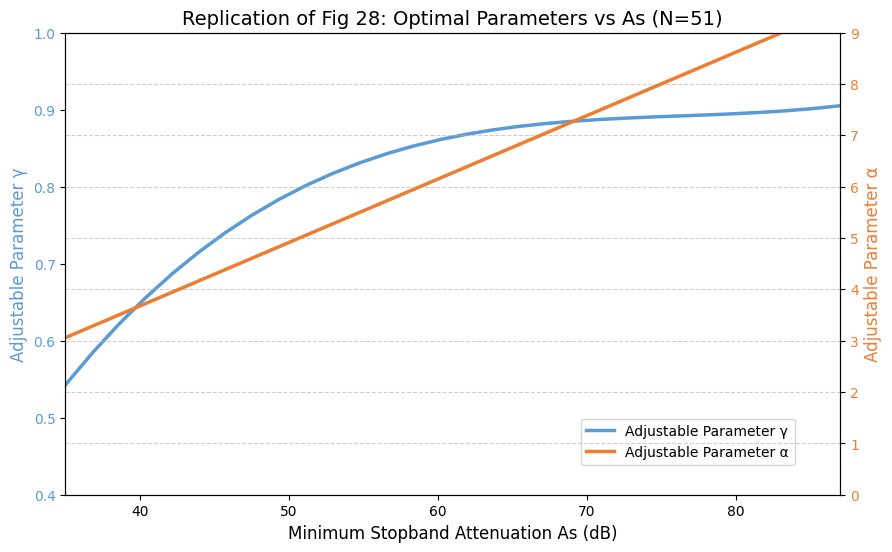

In [13]:
from scipy.optimize import minimize_scalar

def get_metrics(N, alpha, gamma_val):

    w = fractional_kaiser_window(N, alpha, gamma_val)
    # 使用足夠的 FFT 點數確保測量準確
    fft_size = 8192 
    w_freq, H = freqz(w, 1, worN=fft_size) 
    
    mag = np.abs(H)
    max_mag = np.max(mag)
    
    # 轉換成 dB
    with np.errstate(divide='ignore'):
        H_db = 20 * np.log10(mag / max_mag + 1e-15)
        
    first_null_idx = np.argmin(mag[:fft_size//2]) 

    for i in range(1, len(mag)-1):
        if mag[i] < mag[i-1] and mag[i] < mag[i+1]:
            first_null_idx = i
            break
            
    if first_null_idx < len(mag) - 1:
        max_sidelobe = np.max(mag[first_null_idx:])
        As = -20 * np.log10(max_sidelobe / max_mag + 1e-15)
    else:
        As = 0
        
    wr = w_freq[first_null_idx]
    
    return As, wr

def replicate_figure_28_precise():
    N = 51
    # 設定目標 As 範圍 (從 35 到 85 dB)
    target_As_values = np.linspace(35, 87, 30)
    
    optimal_results = []
#---    
    # 為了加速，建立一個參數網格，然後在網格中搜尋
    # 這是比 minimize 函數更穩健的方法，因為曲面可能不平滑
    alphas = np.linspace(1.0, 9.0, 80)      # Alpha 範圍
    gammas = np.linspace(0.4, 0.995, 60)    # Gamma 範圍
    #把 α、γ 切成網格（80×60 = 4800 組參數），每組都算一次 (As, wr)。
    # 預先計算網格 (Grid Search)
    grid_results = []
    for a in alphas:
        for g in gammas:
            As_val, wr_val = get_metrics(N, a, g)
            grid_results.append((As_val, wr_val, a, g))
            #每一列是這四個值：(As, wr, α, γ)
    grid_results = np.array(grid_results)
    
    # 針對每個目標 As，找出最佳參數
    
    final_alpha = []
    final_gamma = []
    final_As = []
    
    tolerance = 1.0 # 容許的 As 誤差範圍 (+/- 1 dB)
    
    for target_As in target_As_values:
        # 1. 篩選出 As 在目標附近的點
        mask = (grid_results[:, 0] >= target_As - tolerance) & \
               (grid_results[:, 0] <= target_As + tolerance)
        candidates = grid_results[mask]
        
        if len(candidates) > 0:
            # 2. 在這些候選者中，找出 Wr (Mainlobe Width) 最小的
            # 論文邏輯：同樣的 As，頻寬越窄越好
            best_idx = np.argmin(candidates[:, 1])
            best_point = candidates[best_idx]
#在 As 接近目標的候選點中，挑主瓣最窄（ω_R 最小）的那組 α、γ。
#----
            # 記錄結果
            final_As.append(target_As) # 使用目標值作為 X 軸，或使用實際值 best_point[0]
            final_alpha.append(best_point[2])
            final_gamma.append(best_point[3])
            
    plt.figure(figsize=(10, 6))
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    
    color_g = '#5B9BD5' # Blue
    color_a = '#ED7D31' # Orange
    
    # 使用平滑曲線連接 (Polynomial Fit)
    z_g = np.polyfit(final_As, final_gamma, 3) # Gamma 是曲線
    p_g = np.poly1d(z_g)
    
    z_a = np.polyfit(final_As, final_alpha, 1) # Alpha 是直線
    p_a = np.poly1d(z_a)
    
    # 繪製曲線
    ax1.plot(final_As, p_g(final_As), color=color_g, linewidth=2.5, label='Adjustable Parameter γ')
    ax2.plot(final_As, p_a(final_As), color=color_a, linewidth=2.5, label='Adjustable Parameter α')
    
    # 為了驗證，也可以畫出實際搜尋到的點 (可選)
    # ax1.scatter(final_As, final_gamma, color=color_g, s=10, alpha=0.5)
    # ax2.scatter(final_As, final_alpha, color=color_a, s=10, alpha=0.5)

    # 設定軸範圍 (依照論文)
    ax1.set_xlim(35, 87)
    ax1.set_ylim(0.4, 1.0)
    ax1.set_xlabel('Minimum Stopband Attenuation As (dB)', fontsize=12)
    ax1.set_ylabel('Adjustable Parameter γ', color=color_g, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color_g)
    
    ax2.set_ylim(0, 9)
    ax2.set_ylabel('Adjustable Parameter α', color=color_a, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_a)
    
    plt.title('Replication of Fig 28: Optimal Parameters vs As (N=51)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', bbox_to_anchor=(0.95, 0.05))
    
    plt.show()

replicate_figure_28_precise()

![Fig. 6](images/圖28.png)

- 如同前面 **圖8( N = 51 時 調alpha)** 與 **表格5 (N = 51 時 調gamma)** 都可以提高As，所以做了一個最佳化的參數尋找在N=51時，($\alpha$)以及($\gamma$) 才能得到最佳解

| 項目 | 說明 | 
|---|---|
| **我的結果** | ($\alpha$) 是線性的形式，($\gamma$) 是飽和曲線：從低處 ($\approx 0.55$) 爬升，然後在高處 ($\approx 0.75$) 變平、飽和。 |  
| **跟論文比較** | 數據趨勢一樣，但線性的起始點以及飽和曲線的爬升幅度不如預期 |  
|**為甚麼不如預期?**|論文原文如下並未說明 他們怎麼做出最佳化|

>These relationships are obtained by varying the α values while keeping the filter length fixed at N = 51


## 2. 比較分數階凱薩窗(gamma>1)(gamma<1)與傳統凱薩窗效能

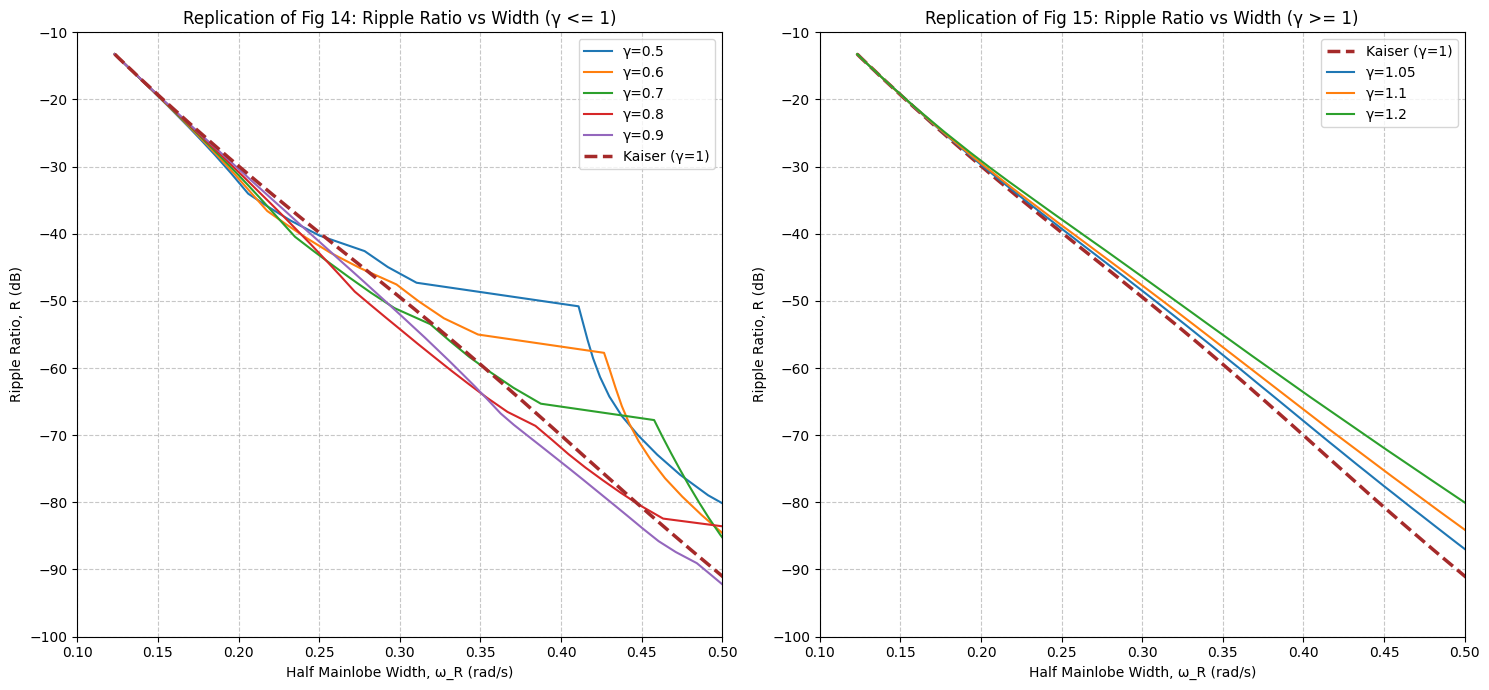

In [ ]:
def measure_window_properties_smooth(N, alpha, gamma_val):
    w = fractional_kaiser_window(N, alpha, gamma_val)
    
    fft_size = 8192 * 4 
    w_freq, H = freqz(w, 1, worN=fft_size) # w_freq: 0 ~ pi
    
    mag = np.abs(H)
    max_mag = np.max(mag)
    # 轉成 dB
    with np.errstate(divide='ignore'):
        H_db = 20 * np.log10(mag / max_mag + 1e-15)
    
    first_null_idx = 0
    for i in range(1, len(mag)-5):

        if mag[i] < mag[i-1] and mag[i] < mag[i+1]:
            first_null_idx = i
            break

    omega_R = w_freq[first_null_idx]
    
    # 測量 Ripple Ratio (R) 
    # 在第一個 Null 之後尋找最大值 (Max Sidelobe)
    if first_null_idx < len(mag) - 1:
        sidelobe_region = mag[first_null_idx:]
        max_sidelobe = np.max(sidelobe_region)
        R_dB = 20 * np.log10(max_sidelobe / max_mag + 1e-15)
    else:
        R_dB = -100.0
        
    return omega_R, R_dB

def plot_figure_14_15_corrected():
    N = 51
    
    # 點數增加到 150 以確保曲線平滑
    alphas = np.linspace(0.0, 25.0, 150) 
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    #  Figure 14: Gamma <= 1 
    gammas_low = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    
    for g in gammas_low:
        wr_list = []
        r_list = []
        for a in alphas:
            wr, r = measure_window_properties_smooth(N, a, g)
            
            if wr > 0.05 and r > -120: 
                wr_list.append(wr)
                r_list.append(r)
        
        label = 'Kaiser (γ=1)' if g == 1.0 else f'γ={g}'
        style = '--' if g == 1.0 else '-'
        lw = 2.5 if g == 1.0 else 1.5
        color = 'brown' if g == 1.0 else None
        
        ax1.plot(wr_list, r_list, label=label, linestyle=style, linewidth=lw, color=color)
        
    ax1.set_title('Replication of Fig 14: Ripple Ratio vs Width (γ <= 1)')
    ax1.set_xlabel('Half Mainlobe Width, ω_R (rad/s)')
    ax1.set_ylabel('Ripple Ratio, R (dB)')
    ax1.set_ylim(-100, -10) 
    ax1.set_xlim(0.1, 0.5)
    ax1.grid(True, which='both', linestyle='--', alpha=0.7)
    ax1.legend()

    # --- Figure 15: Gamma >= 1 ---
    gammas_high = [1.0, 1.05, 1.1, 1.2] 
    
    for g in gammas_high:
        wr_list = []
        r_list = []
        for a in alphas:
            wr, r = measure_window_properties_smooth(N, a, g)
            if wr > 0.05 and r > -120:
                wr_list.append(wr)
                r_list.append(r)
            
        label = 'Kaiser (γ=1)' if g == 1.0 else f'γ={g}'
        style = '--' if g == 1.0 else '-'
        lw = 2.5 if g == 1.0 else 1.5
        color = 'brown' if g == 1.0 else None
        
        ax2.plot(wr_list, r_list, label=label, linestyle=style, linewidth=lw, color=color)

    ax2.set_title('Replication of Fig 15: Ripple Ratio vs Width (γ >= 1)')
    ax2.set_xlabel('Half Mainlobe Width, ω_R (rad/s)')
    ax2.set_ylabel('Ripple Ratio, R (dB)')
    ax2.set_ylim(-100, -10)
    ax2.set_xlim(0.1, 0.5)
    ax2.grid(True, which='both', linestyle='--', alpha=0.7)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

plot_figure_14_15_corrected()

<div style="display:flex; gap:20px; justify-content:center;">

  <div style="width:48%;">
    <img src="images/圖14.png" style="width:100%;">
  </div>

  <div style="width:48%;">
    <img src="images/圖15.png" style="width:100%;">
  </div>

</div>


1. gamma<1
2. gamma = 1
3. gamma >1

 - half mainlobe width的單位是 rad/s，定義為數值越小越好（代表濾波器的頻率響應越接近理想的垂直切斷）

| 項目 | 說明 | 
|---|---|
| **預期上** | 效能($\gamma \le 1$)，gamma<1，效能比gamma=1傳統凱薩窗還好。 ($\gamma \ge 1$)，性能會比傳統的 Kaiser 還差。|  
| **我的結果** | 符合預期，gamma<1，且(0.7 0.8 0.9)效能比gamma=1凱薩窗還好 |  
| **跟論文比較** | 數據趨勢大致相符，但伴隨最大旁瓣高度越小，隨之抑制效果也有差 |  
|**結論**|證明gamma<1 比較好，且gamma = 0.9 是不錯的參數選擇|


正在生成 Figure 27 數據 (Kaiser)...
正在生成 Figure 27 數據 (Proposed Gamma=0.9)...


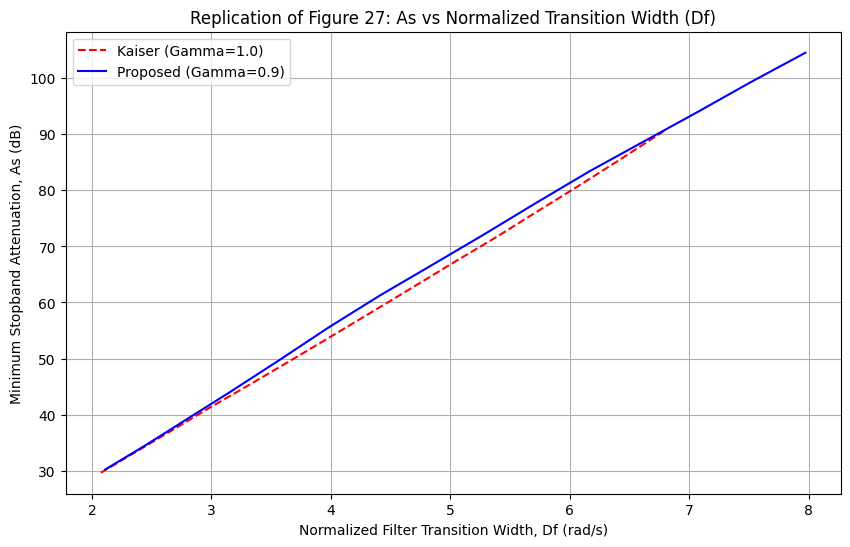

In [ ]:
def measure_transition_width(w_rad, H_db, wc, As):
    # 尋找 -3dB 點
    idx_3db = np.where(H_db <= -3)[0]
    if len(idx_3db) > 0:
        w_3db = w_rad[idx_3db[0]]
    else:
        w_3db = wc # Fallback
        
    # 尋找進入阻帶點
    # Stopband threshold: 稍微高於 As (例如高 1dB)，代表剛進入阻帶
    threshold = -(As - 1.0)
    # 必須在 wc 之後
    mask = (w_rad > wc) & (H_db <= threshold)
    idx_stop = np.where(mask)[0]
    
    if len(idx_stop) > 0:
        w_stop = w_rad[idx_stop[0]]
    else:
        w_stop = w_rad[-1]
        
    delta_w = 2 * (w_stop - w_3db)
    return delta_w

def generate_figure_27_data():
    N = 51
    wc = 0.4 * np.pi
    
    # Kaiser Sweep
    alphas_kaiser = np.linspace(2, 9, 15)
    kaiser_data = []
    
    #print("\n正在生成 Figure 27 數據 (Kaiser)...")
    for alpha in alphas_kaiser:
        # Gamma=1 即為 Kaiser
        h, _ = design_fir_filter(N, wc, alpha, 1.0)
        w_rad, H_db = analyze_filter_spectrum(h)
        As = measure_metrics(w_rad, H_db, wc)
        # 用 As 反推或測量 Df
        dw = measure_transition_width(w_rad, H_db, wc, As)
        Df = dw * (N - 1) / (2 * np.pi)
        kaiser_data.append((Df, As))
        
    # Proposed Sweep (Gamma < 1, e.g., 0.9)
    # 論文 Table 3 [cite: 1943] 顯示 gamma=0.9 時表現很好
    #print("正在生成 Figure 27 數據 (Proposed Gamma=0.9)...")
    proposed_data = []
    alphas_prop = np.linspace(2, 9, 15)
    
    for alpha in alphas_prop:
        gamma_val = 0.9 # 固定一個優良參數展示
        h, _ = design_fir_filter(N, wc, alpha, gamma_val)
        w_rad, H_db = analyze_filter_spectrum(h)
        As = measure_metrics(w_rad, H_db, wc)
        dw = measure_transition_width(w_rad, H_db, wc, As)
        Df = dw * (N - 1) / (2 * np.pi)#公式37
        proposed_data.append((Df, As))
        
    return kaiser_data, proposed_data

def plot_figure_27():
    k_data, p_data = generate_figure_27_data()
    
    k_df = np.array(k_data)
    p_df = np.array(p_data)
    
    k_df = k_df[k_df[:,0].argsort()]
    p_df = p_df[p_df[:,0].argsort()]
    
    plt.figure(figsize=(10, 6))
    plt.plot(k_df[:,0], k_df[:,1], 'r--', label='Kaiser (Gamma=1.0)')
    plt.plot(p_df[:,0], p_df[:,1], 'b-', label='Proposed (Gamma=0.9)')
    
    plt.title('Replication of Figure 27: As vs Normalized Transition Width (Df)')
    plt.xlabel('Normalized Filter Transition Width, Df (rad/s)')
    plt.ylabel('Minimum Stopband Attenuation, As (dB)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_figure_27()

![Fig. 6](images/圖27.png)

| 項目 | 說明 | 
|---|---|
| **預期上** | 分數階凱薩窗gamma<1，抑制效能要比傳統gamma=1還好 |  
| **我的結果** | 符合預期，但抑制效能並沒有明顯高多少 |  
| **跟論文比較** | 趨勢相同，論文圖抑制效果更好了一點，但整個數值並沒有高太多 |  
|**結論**|承襲前面提及的gamma = 0.9，證明論文所強調的創新""分數皆凱薩窗效能比傳統凱薩窗還要好""的這個創新，如我實作的圖27是個很好的證明|







## 3. 分數階凱薩窗(gamma<1)與II.WINDOWFUNCTIONSINLITERATURE A. FIXEDWINDOWS段落中所提到的不同窗函數做比較

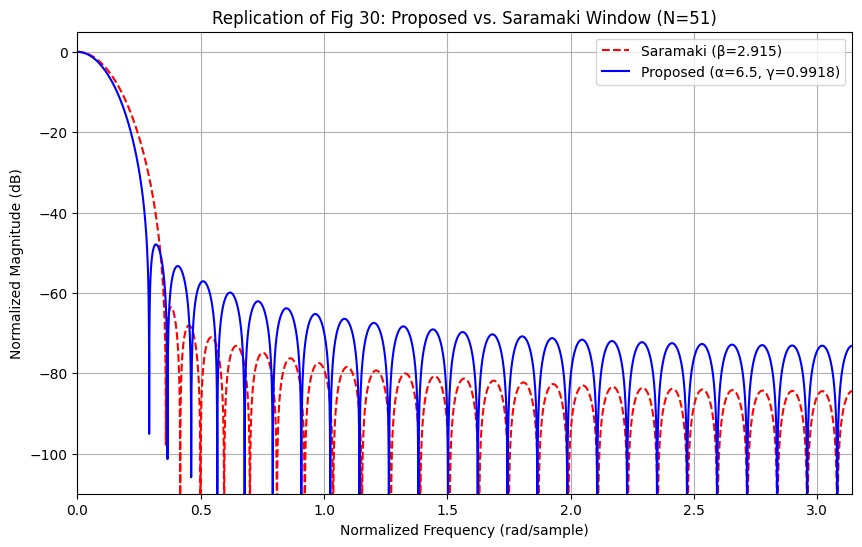

In [2]:
# 核心函數：Saramaki Window (根據論文 Eq. 17-22 實作) ---
def saramaki_window(N, beta):
    # 參考論文公式實作
    # Eq. 22: gamma_s
    gamma_s = (1 + np.cos(2 * np.pi / N)) / (1 + np.cos(2 * beta * np.pi / N))
    
    # 遞迴計算 v_k(n)
    # v 的索引 k 從 0 到 K_max
    # 每個 v[k] 是一個長度為 N 的陣列
    v = [] 
    
    # v0(n): 在中心點為 1，其餘為 0
    v0 = np.zeros(N)
    center_idx = (N - 1) // 2
    if N % 2 != 0:
        v0[int(center_idx)] = 1.0
    v.append(v0)
    
    # v1(n): 中心點為 gamma_s - 1, 左右各為 gamma_s / 2
    v1 = np.zeros(N)
    if N % 2 != 0:
        idx = int(center_idx)
        v1[idx] = gamma_s - 1
        v1[idx - 1] = gamma_s / 2
        v1[idx + 1] = gamma_s / 2
    v.append(v1)
    
    # 遞迴計算 k >= 2
    # Eq. 21
    K_max = int((N - 1) / 2)
    for k in range(2, K_max + 1):
        prev1 = v[k-1] # v_{k-1}
        prev2 = v[k-2] # v_{k-2}
        
        # 位移操作
        prev1_right = np.roll(prev1, 1); prev1_right[0] = 0
        prev1_left = np.roll(prev1, -1); prev1_left[-1] = 0
        
        vk = 2 * (gamma_s - 1) * prev1 - prev2 + gamma_s * (prev1_right + prev1_left)
        v.append(vk)
        
    # Eq. 18: w_hat(n) = v0 + 2 * sum(vk)
    w_hat = v[0].copy()
    for k in range(1, K_max + 1):
        w_hat += 2 * v[k]
        
    # 歸一化: w(n) = w_hat(n) / w_hat(0)
    w = w_hat / w_hat[int(center_idx)]
    return w

def plot_figure_30():
    N = 51
    
    # 參數設定 (依據論文 Figure 19 的典型比較參數)
    # 目標：讓主瓣寬度一樣，看誰旁瓣低
    
    # Proposed Window 參數
    alpha_prop = 6.5
    gamma_prop = 0.9918 
    
    # Saramaki Window 參數
    beta_sara = 2.915
    
    # 產生窗函數
    w_prop = fractional_kaiser_window(N, alpha_prop, gamma_prop)
    w_sara = saramaki_window(N, beta_sara)
    
    # 計算頻譜
    fft_size = 8192
    
    # Proposed Spectrum
    f_p, H_p = freqz(w_prop, 1, worN=fft_size)
    H_p_db = 20 * np.log10(np.abs(H_p) / np.max(np.abs(H_p)) + 1e-15)
    
    # Saramaki Spectrum
    f_s, H_s = freqz(w_sara, 1, worN=fft_size)
    H_s_db = 20 * np.log10(np.abs(H_s) / np.max(np.abs(H_s)) + 1e-15)
    
    # 繪圖
    plt.figure(figsize=(10, 6))
    
    # 繪製 Saramaki (虛線)
    plt.plot(f_s, H_s_db, 'r--', linewidth=1.5, label=f'Saramaki (β={beta_sara})')
    
    # 繪製 Proposed (實線)
    plt.plot(f_p, H_p_db, 'b-', linewidth=1.5, label=f'Proposed (α={alpha_prop}, γ={gamma_prop})')
    
    plt.title('Replication of Fig 30: Proposed vs. Saramaki Window (N=51)')
    plt.xlabel('Normalized Frequency (rad/sample)')
    plt.ylabel('Normalized Magnitude (dB)')
    plt.legend()
    plt.grid(True)
    
    # 設定範圍以符合論文觀感
    plt.ylim(-110, 5)
    plt.xlim(0, np.pi)
    
    plt.show()

plot_figure_30()

![Fig. 6](images/saramaki.png)

| 項目 | 說明 | 
|---|---|
| **預期上** | 分數階凱薩窗設計的濾波器效能要比論文提及的舊方法或是其他窗函數抑制吉布絲震盪的效能還好 |  
| **我的結果** | 符合預期，主辦更窄，旁瓣更大，整體壓抑效果更好 |  
| **跟論文比較** | 行為、結果、趨勢皆相同 |  


### 結論:
1. 觀察上述圖表，整體數據趨勢皆與論文相同，僅公式函數復刻時有落差導致數據不同
2. 透過圖28可以達到參數alpha gamma最佳化
3. 圖27 強力證明作者的分數階創新
4. 圖30 作者的創新"分數階凱薩窗不只比傳統凱薩窗好"，還比其他種窗函數還好